**Edited By Saeed**

# Project Deliverable 2 – Machine Learning Model Report

## Course: CDS 2413 – Introduction to Data Science

**Dataset:** `student_habits_performance.csv`

This notebook implements the full CLO3 pipeline required by Deliverable 2:

1. **Preprocessing** – data collection, cleaning, categorical encoding, splitting, feature scaling
2. **Regression** – Multiple Linear, Polynomial, Ridge, Lasso, Elastic Net (compared by R² and MSE)
3. **Classification** – Logistic Regression, KNN, SVM, Decision Tree, Random Forest (compared by accuracy, precision, recall, F1)
4. **Clustering** – K-Means and Hierarchical with cluster strategy formulation

The dependent variable for **regression** is `exam_score`. For **classification**, the target is derived as a binary `Pass / Fail` label using a 50-mark threshold.

## Importing the libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet, LogisticRegression
from sklearn.metrics import (mean_squared_error, r2_score,
                             accuracy_score, precision_score, recall_score, f1_score,
                             confusion_matrix, classification_report)
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.cluster import KMeans, AgglomerativeClustering
import scipy.cluster.hierarchy as sch

import warnings
warnings.filterwarnings('ignore')

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# Preprocessing

## Importing the dataset (Data Collection)

We load the dataset using **pandas** `read_csv`. The dependent (target) variable for regression is `exam_score`; the remaining columns become independent variables.

In [2]:
dataset = pd.read_csv('student_habits_performance.csv')
print('Shape:', dataset.shape)
dataset.head()

Shape: (1000, 16)


,student_id,age,gender,study_hours_per_day,social_media_hours,netflix_hours,part_time_job,attendance_percentage,sleep_hours,diet_quality,exercise_frequency,parental_education_level,internet_quality,mental_health_rating,extracurricular_participation,exam_score
0,S1000,23,Female,0.0,1.2,1.1,No,85.0,8.0,Fair,6,Master,Average,8,Yes,56.2
1,S1001,20,Female,6.9,2.8,2.3,No,97.3,4.6,Good,6,High School,Average,8,No,100.0
2,S1002,21,Male,1.4,3.1,1.3,No,94.8,8.0,Poor,1,High School,Poor,1,No,34.3
3,S1003,23,Female,1.0,3.9,1.0,No,71.0,9.2,Poor,4,Master,Good,1,Yes,26.8
4,S1004,19,Female,5.0,4.4,0.5,No,90.9,4.9,Fair,3,Master,Good,1,No,66.4


In [3]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 16 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   student_id                     1000 non-null   object 
 1   age                            1000 non-null   int64  
 2   gender                         1000 non-null   object 
 3   study_hours_per_day            1000 non-null   float64
 4   social_media_hours             1000 non-null   float64
 5   netflix_hours                  1000 non-null   float64
 6   part_time_job                  1000 non-null   object 
 7   attendance_percentage          1000 non-null   float64
 8   sleep_hours                    1000 non-null   float64
 9   diet_quality                   1000 non-null   object 
 10  exercise_frequency             1000 non-null   int64  
 11  parental_education_level       909 non-null    object 
 12  internet_quality               1000 non-null   ob

## Data Cleaning

We check for missing values and duplicates. The only column with missing values is `parental_education_level` (91 NaNs). Because it is a categorical variable, we impute with the **mode**. We also drop `student_id` since it is a unique identifier and carries no predictive information.

In [4]:
# Missing values per column
print('Missing values per column:')
print(dataset.isnull().sum())
print('\nDuplicate rows:', dataset.duplicated().sum())

Missing values per column:
student_id                        0
age                               0
gender                            0
study_hours_per_day               0
social_media_hours                0
netflix_hours                     0
part_time_job                     0
attendance_percentage             0
sleep_hours                       0
diet_quality                      0
exercise_frequency                0
parental_education_level         91
internet_quality                  0
mental_health_rating              0
extracurricular_participation     0
exam_score                        0
dtype: int64

Duplicate rows: 0


In [5]:
# Impute parental_education_level with the mode
mode_pe = dataset['parental_education_level'].mode()[0]
dataset['parental_education_level'] = dataset['parental_education_level'].fillna(mode_pe)

# Drop student_id (identifier, not a feature)
dataset = dataset.drop(columns=['student_id'])

print('After cleaning - missing values:', dataset.isnull().sum().sum())
print('Shape:', dataset.shape)

After cleaning - missing values: 0
Shape: (1000, 15)


## Treating the Categorical Variables

The dataset contains three types of categorical variables:

| Type | Variables | Encoding |
|---|---|---|
| **Binary** | `part_time_job`, `extracurricular_participation` | Map Yes→1, No→0 |
| **Ordinal** | `diet_quality` (Poor<Fair<Good), `internet_quality` (Poor<Average<Good), `parental_education_level` (HS<Bachelor<Master) | Label encoding preserving order |
| **Nominal** | `gender` (Female, Male, Other) | One-hot encoding (drop first to avoid the dummy-variable trap) |

This way ordinal information is retained while nominal categories are not given an artificial order.

In [6]:
# Binary encoding
dataset['part_time_job'] = dataset['part_time_job'].map({'No': 0, 'Yes': 1})
dataset['extracurricular_participation'] = dataset['extracurricular_participation'].map({'No': 0, 'Yes': 1})

# Ordinal encoding
dataset['diet_quality']             = dataset['diet_quality'].map({'Poor': 0, 'Fair': 1, 'Good': 2})
dataset['internet_quality']         = dataset['internet_quality'].map({'Poor': 0, 'Average': 1, 'Good': 2})
dataset['parental_education_level'] = dataset['parental_education_level'].map(
    {'High School': 0, 'Bachelor': 1, 'Master': 2}
)

# Nominal one-hot encoding for gender
dataset = pd.get_dummies(dataset, columns=['gender'], drop_first=True)
for col in dataset.columns:
    if dataset[col].dtype == bool:
        dataset[col] = dataset[col].astype(int)

dataset.head()

,age,study_hours_per_day,social_media_hours,netflix_hours,part_time_job,attendance_percentage,sleep_hours,diet_quality,exercise_frequency,parental_education_level,internet_quality,mental_health_rating,extracurricular_participation,exam_score,gender_Male,gender_Other
0,23,0.0,1.2,1.1,0,85.0,8.0,1,6,2,1,8,1,56.2,0,0
1,20,6.9,2.8,2.3,0,97.3,4.6,2,6,0,1,8,0,100.0,0,0
2,21,1.4,3.1,1.3,0,94.8,8.0,0,1,0,0,1,0,34.3,1,0
3,23,1.0,3.9,1.0,0,71.0,9.2,0,4,2,2,1,1,26.8,0,0
4,19,5.0,4.4,0.5,0,90.9,4.9,1,3,2,2,1,0,66.4,0,0


## Detecting and Removing Outliers (IQR Method)

For each numeric independent variable, values outside `[Q1 − 1.5·IQR, Q3 + 1.5·IQR]` are flagged as outliers. Indices are combined and de-duplicated, then the corresponding rows are removed to improve regression-model performance.

In [7]:
numeric_cols = ['study_hours_per_day', 'social_media_hours', 'netflix_hours',
                'attendance_percentage', 'sleep_hours', 'mental_health_rating']

outlier_indices = set()
for col in numeric_cols:
    Q1 = dataset[col].quantile(0.25)
    Q3 = dataset[col].quantile(0.75)
    IQR = Q3 - Q1
    lower, upper = Q1 - 1.5 * IQR, Q3 + 1.5 * IQR
    out_idx = dataset[(dataset[col] < lower) | (dataset[col] > upper)].index
    print(f'{col:>25s}: {len(out_idx):3d} outliers, accept range = [{lower:7.2f}, {upper:7.2f}]')
    outlier_indices.update(out_idx)

print(f'\nTotal unique outlier rows: {len(outlier_indices)}')
dataset = dataset.drop(index=list(outlier_indices)).reset_index(drop=True)
print(f'Shape after removing outliers: {dataset.shape}')

      study_hours_per_day:   7 outliers, accept range = [  -0.25,    7.35]
       social_media_hours:   5 outliers, accept range = [  -0.70,    5.70]
            netflix_hours:   4 outliers, accept range = [  -1.29,    4.81]
    attendance_percentage:   3 outliers, accept range = [  58.46,  110.56]
              sleep_hours:   2 outliers, accept range = [   3.05,    9.85]
     mental_health_rating:   0 outliers, accept range = [  -4.50,   15.50]

Total unique outlier rows: 21
Shape after removing outliers: (979, 16)


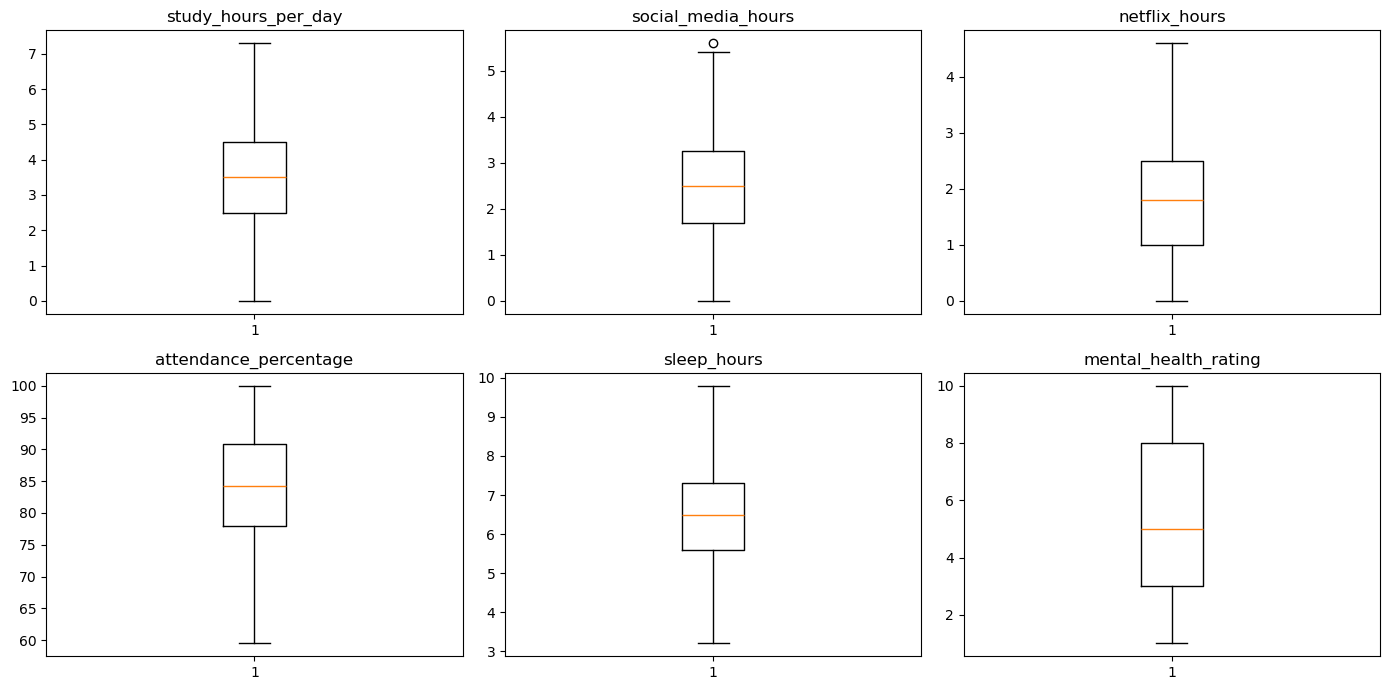

In [8]:
# Visualise distributions of key numeric variables (after outlier removal)
fig, axes = plt.subplots(2, 3, figsize=(14, 7))
for ax, col in zip(axes.flat, numeric_cols):
    ax.boxplot(dataset[col], vert=True)
    ax.set_title(col)
plt.tight_layout()
plt.show()

## Splitting the dataset into Training and Test sets

We split features (`X`) from the target (`y = exam_score`). The dataset is divided 80% training / 20% testing using `train_test_split`. An 80/20 split provides enough data to learn from while leaving a representative held-out set for evaluation.

In [9]:
y = dataset['exam_score'].values
X = dataset.drop(columns=['exam_score']).values
feature_names = dataset.drop(columns=['exam_score']).columns.tolist()
print('Features:', feature_names)
print('X shape:', X.shape, '   y shape:', y.shape)

Features: ['age', 'study_hours_per_day', 'social_media_hours', 'netflix_hours', 'part_time_job', 'attendance_percentage', 'sleep_hours', 'diet_quality', 'exercise_frequency', 'parental_education_level', 'internet_quality', 'mental_health_rating', 'extracurricular_participation', 'gender_Male', 'gender_Other']
X shape: (979, 15)    y shape: (979,)


In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE)
print('Training set:', X_train.shape, '  Test set:', X_test.shape)

Training set: (783, 15)   Test set: (196, 15)


## Feature Scaling

We apply **StandardScaler** (z-score scaling) so all features have mean ≈ 0 and standard deviation ≈ 1. This is important for regularised regressions (Ridge, Lasso, Elastic Net) and distance-based classifiers (KNN, SVM) because they are sensitive to the magnitude of features. The scaler is fitted on `X_train` only and then applied to `X_test` to avoid data leakage.

In [11]:
sc = StandardScaler()
X_train_sc = sc.fit_transform(X_train)
X_test_sc  = sc.transform(X_test)

# Regression Model

## Building the Regression Models

We build five regression models and compare them on the held-out test set using **MSE** and **R²**.

### 1. Multiple Linear Regression

In [12]:
lr = LinearRegression()
lr.fit(X_train_sc, y_train)
y_pred_lr = lr.predict(X_test_sc)

mse_lr = mean_squared_error(y_test, y_pred_lr)
r2_lr  = r2_score(y_test, y_pred_lr)
print(f'MSE = {mse_lr:.4f}    R² = {r2_lr:.4f}')

MSE = 31.1946    R² = 0.8854


### 2. Polynomial Regression (degree = 2)

In [13]:
poly = PolynomialFeatures(degree=2, include_bias=False)
X_train_poly = poly.fit_transform(X_train_sc)
X_test_poly  = poly.transform(X_test_sc)

poly_reg = LinearRegression()
poly_reg.fit(X_train_poly, y_train)
y_pred_poly = poly_reg.predict(X_test_poly)

mse_poly = mean_squared_error(y_test, y_pred_poly)
r2_poly  = r2_score(y_test, y_pred_poly)
print(f'MSE = {mse_poly:.4f}    R² = {r2_poly:.4f}')

MSE = 30.9021    R² = 0.8865


### 3. Ridge Regression (L2 regularisation)

In [14]:
ridge = Ridge(alpha=1.0, random_state=RANDOM_STATE)
ridge.fit(X_train_sc, y_train)
y_pred_ridge = ridge.predict(X_test_sc)

mse_ridge = mean_squared_error(y_test, y_pred_ridge)
r2_ridge  = r2_score(y_test, y_pred_ridge)
print(f'MSE = {mse_ridge:.4f}    R² = {r2_ridge:.4f}')

MSE = 31.2128    R² = 0.8854


### 4. Lasso Regression (L1 regularisation)

In [15]:
lasso = Lasso(alpha=0.1, random_state=RANDOM_STATE, max_iter=10000)
lasso.fit(X_train_sc, y_train)
y_pred_lasso = lasso.predict(X_test_sc)

mse_lasso = mean_squared_error(y_test, y_pred_lasso)
r2_lasso  = r2_score(y_test, y_pred_lasso)
print(f'MSE = {mse_lasso:.4f}    R² = {r2_lasso:.4f}')

MSE = 30.7036    R² = 0.8872


### 5. Elastic Net Regression (L1 + L2)

In [16]:
en = ElasticNet(alpha=0.1, l1_ratio=0.5, random_state=RANDOM_STATE, max_iter=10000)
en.fit(X_train_sc, y_train)
y_pred_en = en.predict(X_test_sc)

mse_en = mean_squared_error(y_test, y_pred_en)
r2_en  = r2_score(y_test, y_pred_en)
print(f'MSE = {mse_en:.4f}    R² = {r2_en:.4f}')

MSE = 32.1786    R² = 0.8818


## Selecting the Best Regression Model

We compare all five models in a single table; the model with the **highest R²** is selected as best-fit.

In [17]:
reg_compare = pd.DataFrame({
    'Model': ['Multiple Linear Regression', 'Polynomial Regression (deg=2)',
              'Ridge Regression', 'Lasso Regression', 'Elastic Net Regression'],
    'MSE':   [mse_lr, mse_poly, mse_ridge, mse_lasso, mse_en],
    'R²':    [r2_lr, r2_poly, r2_ridge, r2_lasso, r2_en]
})
reg_compare = reg_compare.sort_values('R²', ascending=False).reset_index(drop=True)
reg_compare.insert(0, '#', range(1, len(reg_compare) + 1))

best_idx  = reg_compare['R²'].idxmax()
best_name = reg_compare.loc[best_idx, 'Model']
print(f'Best-fit regression model: {best_name}')
print('Table 2 — Regression Results\n')

reg_compare.round({'MSE': 4, 'R²': 4})


Best-fit regression model: Lasso Regression
Table 2 — Regression Results



,#,Model,MSE,R²
0,1,Lasso Regression,30.7036,0.8872
1,2,Polynomial Regression (deg=2),30.9021,0.8865
2,3,Multiple Linear Regression,31.1946,0.8854
3,4,Ridge Regression,31.2128,0.8854
4,5,Elastic Net Regression,32.1786,0.8818


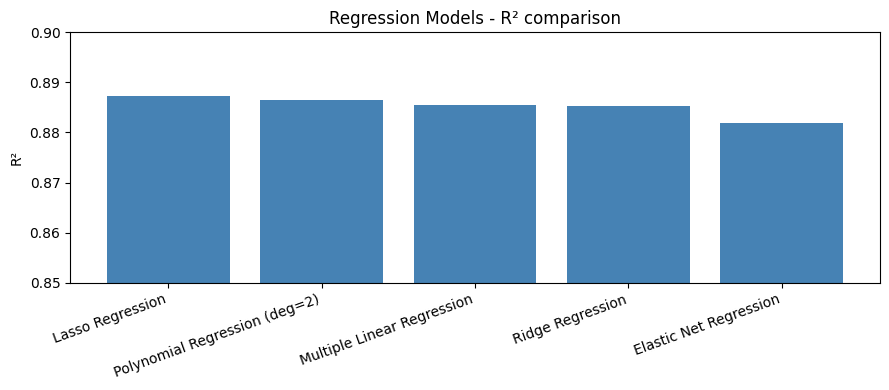

In [18]:
fig, ax = plt.subplots(figsize=(9, 4))
ax.bar(reg_compare['Model'], reg_compare['R²'], color='steelblue')
ax.set_ylabel('R²')
ax.set_title('Regression Models - R² comparison')
ax.set_ylim(0.85, 0.90)
plt.xticks(rotation=20, ha='right')
plt.tight_layout()
plt.show()

## Deriving the Regression Equation

For interpretability we print the **Multiple Linear Regression** coefficients (the linear models all give R² ≈ 0.885, so MLR is a faithful representation of the relationship). The equation has the form

$$\hat{y} = \beta_0 + \beta_1 x_1 + \beta_2 x_2 + \cdots + \beta_p x_p$$

where each `xᵢ` is the **standardised** feature value.

## Manual Prediction on 5 Randomly Sampled Records (Raw-Feature Equation)

The MLR equation above uses *standardised* features, which makes hand-calculation awkward. To make the manual prediction step feasible with pen-and-paper, we refit Multiple Linear Regression on the **raw (unscaled) features** and print:

1. the resulting equation in the original units of each variable, and
2. a worked example for 5 randomly sampled records, so you can verify your hand calculations.



In [17]:
# Refit MLR on RAW (unscaled) features so the equation can be used by hand
lr_raw = LinearRegression()
lr_raw.fit(X_train, y_train)

print(f'Intercept (b0): {lr_raw.intercept_:.4f}')
print('Coefficients (raw units):')
for fn, c in zip(feature_names, lr_raw.coef_):
    print(f'  {fn:>30s}: {c:+.4f}')

# Build a readable equation
print('\nMLR equation (raw features, plug in the actual values from the CSV):')
eq = f'exam_score = {lr_raw.intercept_:.4f}'
for fn, c in zip(feature_names, lr_raw.coef_):
    sign = '+' if c >= 0 else '-'
    eq += f' {sign} {abs(c):.4f} * {fn}'
print(eq)

# ---------- Worked example for 5 random records ----------
print('\n' + '=' * 70)
print('Worked example: 5 randomly sampled records')
print('=' * 70)

sample_idx = np.random.RandomState(7).choice(len(dataset), size=5, replace=False)
sample = dataset.iloc[sample_idx].reset_index(drop=True)

# Predicted values using the raw-feature equation
X_sample = sample.drop(columns=['exam_score']).values
sample_preds = lr_raw.predict(X_sample)
sample_actual = sample['exam_score'].values

result = pd.DataFrame({
    'Row #'    : sample_idx,
    'Observed' : sample_actual,
    'Predicted': sample_preds.round(2),
    'Error'    : (sample_actual - sample_preds).round(2)
})
print(result.to_string(index=False))

# Show the feature values for the 5 rows so you can plug them into the equation by hand
print('\nFeature values for the 5 sampled rows (use these in the equation):')
sample.drop(columns=['exam_score']).round(2)

Intercept (b0): 7.2038
Coefficients (raw units):
                             age: -0.0048
             study_hours_per_day: +9.6120
              social_media_hours: -2.6415
                   netflix_hours: -2.4163
                   part_time_job: +0.3016
           attendance_percentage: +0.1339
                     sleep_hours: +1.9200
                    diet_quality: +0.0790
              exercise_frequency: +1.4826
        parental_education_level: +0.2268
                internet_quality: -0.4447
            mental_health_rating: +2.0198
   extracurricular_participation: +0.1395
                     gender_Male: +0.4280
                    gender_Other: +1.5020

MLR equation (raw features, plug in the actual values from the CSV):
exam_score = 7.2038 - 0.0048 * age + 9.6120 * study_hours_per_day - 2.6415 * social_media_hours - 2.4163 * netflix_hours + 0.3016 * part_time_job + 0.1339 * attendance_percentage + 1.9200 * sleep_hours + 0.0790 * diet_quality + 1.4826 * exercise_frequ

,age,study_hours_per_day,social_media_hours,netflix_hours,part_time_job,attendance_percentage,sleep_hours,diet_quality,exercise_frequency,parental_education_level,internet_quality,mental_health_rating,extracurricular_participation,gender_Male,gender_Other
0,19,3.7,2.9,2.8,0,100.0,6.5,2,6,1,1,8,0,1,0
1,18,2.1,2.1,3.6,0,87.8,5.8,1,5,2,0,4,0,1,0
2,20,4.0,3.4,3.4,1,78.0,5.5,0,3,1,1,7,1,0,0
3,20,3.2,2.0,2.0,0,88.3,4.9,1,4,1,0,4,1,1,0
4,22,5.9,0.0,3.0,0,100.0,6.3,1,2,0,2,1,1,0,0


In [18]:
print(f'Intercept (β₀): {lr.intercept_:.4f}\n')
print('Coefficients:')
for fn, c in zip(feature_names, lr.coef_):
    print(f'  {fn:>30s}: {c:+.4f}')

print('\nMLR equation (standardised features):')
eq = f'exam_score = {lr.intercept_:.4f}'
for fn, c in zip(feature_names, lr.coef_):
    sign = '+' if c >= 0 else '-'
    eq += f' {sign} {abs(c):.4f}*{fn}'
print(eq)

Intercept (β₀): 69.4458

Coefficients:
                             age: -0.0111
             study_hours_per_day: +13.8139
              social_media_hours: -3.0277
                   netflix_hours: -2.5300
                   part_time_job: +0.1251
           attendance_percentage: +1.2467
                     sleep_hours: +2.3328
                    diet_quality: +0.0564
              exercise_frequency: +2.9904
        parental_education_level: +0.1683
                internet_quality: -0.3214
            mental_health_rating: +5.8124
   extracurricular_participation: +0.0654
                     gender_Male: +0.2138
                    gender_Other: +0.3146

MLR equation (standardised features):
exam_score = 69.4458 - 0.0111*age + 13.8139*study_hours_per_day - 3.0277*social_media_hours - 2.5300*netflix_hours + 0.1251*part_time_job + 1.2467*attendance_percentage + 2.3328*sleep_hours + 0.0564*diet_quality + 2.9904*exercise_frequency + 0.1683*parental_education_level - 0.3214*internet

## Visualization: Observed vs Predicted Values

Scatter plot of observed `y_test` versus predicted values from the **best-fit** model. The red diagonal `y = x` represents perfect predictions; points clustered tightly around it indicate strong fit.

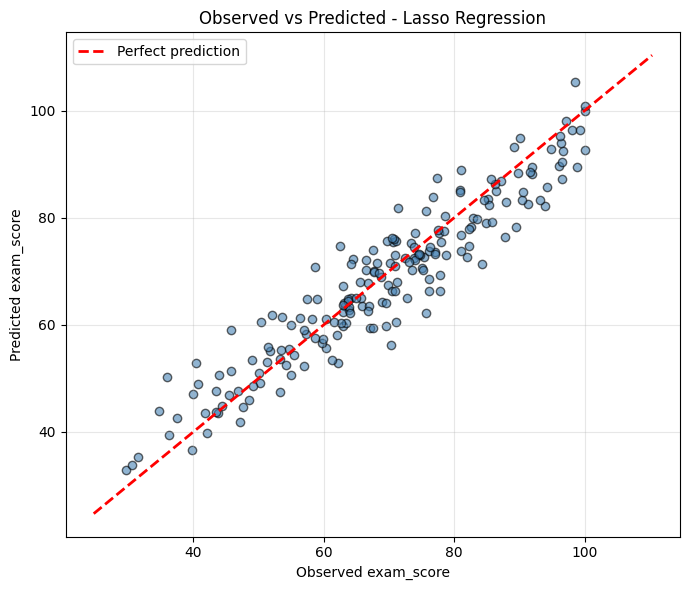

In [20]:
# Use the best model's predictions
best_preds = {'Multiple Linear Regression': y_pred_lr,
              'Polynomial Regression (deg=2)': y_pred_poly,
              'Ridge Regression': y_pred_ridge,
              'Lasso Regression': y_pred_lasso,
              'Elastic Net Regression': y_pred_en}
y_pred_best = best_preds[best_name]

plt.figure(figsize=(7, 6))
plt.scatter(y_test, y_pred_best, alpha=0.6, color='steelblue', edgecolor='k')
lims = [min(y_test.min(), y_pred_best.min()) - 5,
        max(y_test.max(), y_pred_best.max()) + 5]
plt.plot(lims, lims, 'r--', linewidth=2, label='Perfect prediction')
plt.xlabel('Observed exam_score')
plt.ylabel('Predicted exam_score')
plt.title(f'Observed vs Predicted - {best_name}')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Classification Model

## Classifying the dataset based on the target variable

We define the categorical target by applying a 50-mark pass criterion to `exam_score`:

* **Fail (0)** – `exam_score < 50`
* **Pass (1)** – `exam_score ≥ 50`

This produces an interpretable binary outcome aligned with academic grading.

In [21]:
y_class = (dataset['exam_score'] >= 50).astype(int).values
X_clf   = dataset.drop(columns=['exam_score']).values

print('Class distribution:')
print(f'  Fail (0): {(y_class == 0).sum()}')
print(f'  Pass (1): {(y_class == 1).sum()}')

Class distribution:
  Fail (0): 129
  Pass (1): 850


In [22]:
# Train-test split (stratified to preserve class proportions)
X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X_clf, y_class, test_size=0.2, random_state=RANDOM_STATE, stratify=y_class)

# Feature scaling
sc_c = StandardScaler()
X_train_c_sc = sc_c.fit_transform(X_train_c)
X_test_c_sc  = sc_c.transform(X_test_c)

print('Train:', X_train_c_sc.shape, '  Test:', X_test_c_sc.shape)

Train: (783, 15)   Test: (196, 15)


## Building Classification Models

We fit five classifiers and evaluate each on the held-out test set using **accuracy, precision, recall, F1-score, and error count**.

In [23]:
classifiers = {
    'Logistic Regression': LogisticRegression(random_state=RANDOM_STATE, max_iter=2000),
    'KNN':                 KNeighborsClassifier(n_neighbors=5),
    'SVM':                 SVC(kernel='rbf', random_state=RANDOM_STATE),
    'Decision Tree':       DecisionTreeClassifier(random_state=RANDOM_STATE),
    'Random Forest':       RandomForestClassifier(n_estimators=100, random_state=RANDOM_STATE)
}

clf_rows = []
for name, clf in classifiers.items():
    clf.fit(X_train_c_sc, y_train_c)
    y_p = clf.predict(X_test_c_sc)
    clf_rows.append({
        'Model':     name,
        'Errors':    int((y_p != y_test_c).sum()),
        'Accuracy':  accuracy_score(y_test_c, y_p),
        'Precision': precision_score(y_test_c, y_p),
        'Recall':    recall_score(y_test_c, y_p),
        'F1':        f1_score(y_test_c, y_p)
    })

clf_df = pd.DataFrame(clf_rows).sort_values('Accuracy', ascending=False).reset_index(drop=True)
best_clf_name = clf_df.loc[0, 'Model']
print(f'Best-fit classifier: {best_clf_name}')
print('Table 3 — Classification Results\n')

clf_df.round({'Accuracy': 4, 'Precision': 4, 'Recall': 4, 'F1': 4})


Best-fit classifier: Logistic Regression
Table 3 — Classification Results



,Model,Errors,Accuracy,Precision,Recall,F1
0,Logistic Regression,7,0.9643,0.9657,0.9941,0.9797
1,SVM,10,0.9490,0.9444,1.0000,0.9714
2,Random Forest,15,0.9235,0.9235,0.9941,0.9575
3,Decision Tree,18,0.9082,0.9222,0.9765,0.9486
4,KNN,21,0.8929,0.8901,1.0000,0.9418


Classification Report:
              precision    recall  f1-score   support

        Fail       0.95      0.77      0.85        26
        Pass       0.97      0.99      0.98       170

    accuracy                           0.96       196
   macro avg       0.96      0.88      0.92       196
weighted avg       0.96      0.96      0.96       196


Confusion Matrix — Logistic Regression


,Predicted: Fail,Predicted: Pass
Actual: Fail,20,6
Actual: Pass,1,169


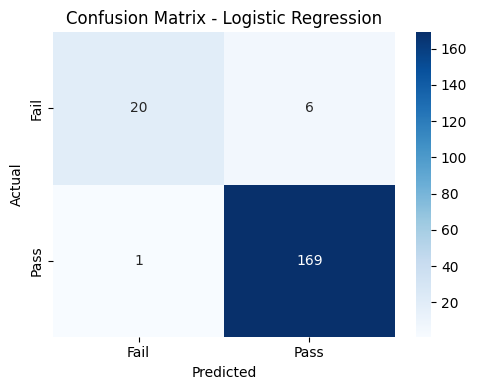

In [24]:
best_clf = classifiers[best_clf_name]
y_pred_best_clf = best_clf.predict(X_test_c_sc)
cm = confusion_matrix(y_test_c, y_pred_best_clf)

# Confusion matrix heatmap
fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Fail', 'Pass'], yticklabels=['Fail', 'Pass'], ax=ax)
ax.set_xlabel('Predicted')
ax.set_ylabel('Actual')
ax.set_title(f'Confusion Matrix - {best_clf_name}')
plt.tight_layout()
plt.show()

print('Classification Report:')
print(classification_report(y_test_c, y_pred_best_clf, target_names=['Fail', 'Pass']))

# Confusion matrix as a labelled table
print(f'\nConfusion Matrix — {best_clf_name}')
cm_df = pd.DataFrame(
    cm,
    index=['Actual: Fail',    'Actual: Pass'],
    columns=['Predicted: Fail', 'Predicted: Pass']
)
cm_df


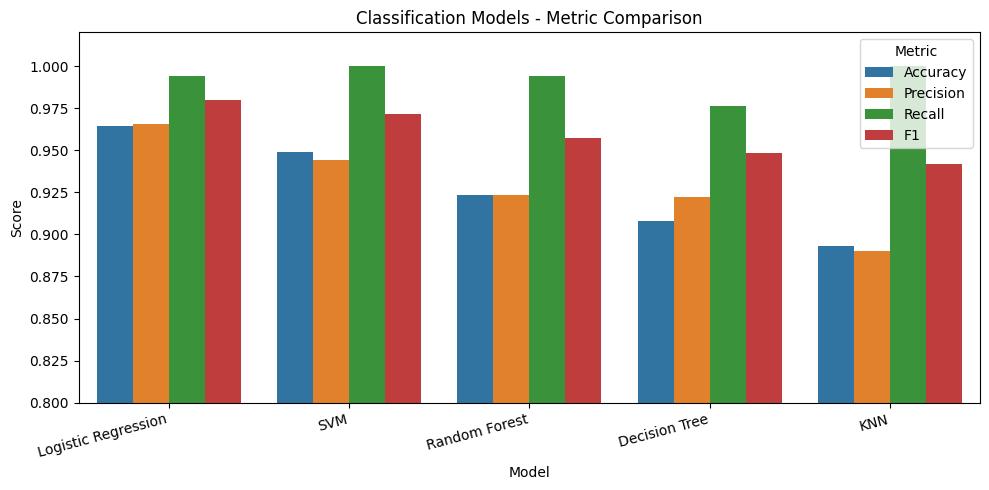

In [25]:
metrics_long = clf_df.melt(id_vars='Model',
                            value_vars=['Accuracy', 'Precision', 'Recall', 'F1'],
                            var_name='Metric', value_name='Score')
plt.figure(figsize=(10, 5))
sns.barplot(data=metrics_long, x='Model', y='Score', hue='Metric')
plt.title('Classification Models - Metric Comparison')
plt.ylim(0.8, 1.02)
plt.xticks(rotation=15, ha='right')
plt.tight_layout()
plt.show()

## Number of elements in each category (best classifier)

We retrain the best classifier on the **full** scaled dataset and report the predicted class counts.

In [26]:
sc_full = StandardScaler()
X_full_sc = sc_full.fit_transform(X_clf)

best_clf_full = type(classifiers[best_clf_name])(**classifiers[best_clf_name].get_params())
best_clf_full.fit(X_full_sc, y_class)
y_full_pred = best_clf_full.predict(X_full_sc)

vals, counts = np.unique(y_full_pred, return_counts=True)
print(f'Predicted elements per category - {best_clf_name}:')
for v, c in zip(vals, counts):
    label = 'Pass' if v == 1 else 'Fail'
    print(f'  {label}: {c}')

print('\nActual class distribution:')
vals, counts = np.unique(y_class, return_counts=True)
for v, c in zip(vals, counts):
    label = 'Pass' if v == 1 else 'Fail'
    print(f'  {label}: {c}')

Predicted elements per category - Logistic Regression:
  Fail: 116
  Pass: 863

Actual class distribution:
  Fail: 129
  Pass: 850


# Cluster Analysis

We perform clustering on the two most informative numeric features — `study_hours_per_day` and `exam_score` — so that clusters can be visualised in 2-D and a clear strategy can be assigned to each segment.

In [27]:
X_clu = dataset[['study_hours_per_day', 'exam_score']].values
print('X_clu shape:', X_clu.shape)

X_clu shape: (979, 2)


## Using the elbow method to find the optimal number of clusters

  k =  1   WCSS =  277970.56
  k =  2   WCSS =   97887.28
  k =  3   WCSS =   45649.51
  k =  4   WCSS =   27612.13
  k =  5   WCSS =   18232.89
  k =  6   WCSS =   12235.25
  k =  7   WCSS =    9187.57
  k =  8   WCSS =    7075.64
  k =  9   WCSS =    5607.87
  k = 10   WCSS =    4523.32


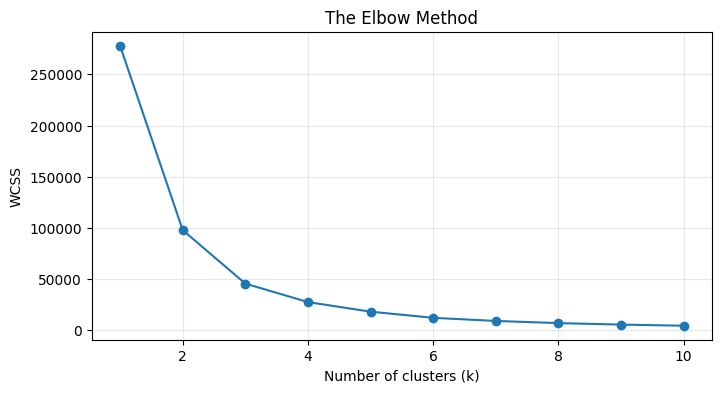

In [28]:
wcss = []
for k in range(1, 11):
    km = KMeans(n_clusters=k, init='k-means++', random_state=RANDOM_STATE, n_init=10)
    km.fit(X_clu)
    wcss.append(km.inertia_)

plt.figure(figsize=(8, 4))
plt.plot(range(1, 11), wcss, marker='o')
plt.title('The Elbow Method')
plt.xlabel('Number of clusters (k)')
plt.ylabel('WCSS')
plt.grid(alpha=0.3)
plt.show()

for k, w in enumerate(wcss, 1):
    print(f'  k = {k:2d}   WCSS = {w:10.2f}')

The elbow appears at **k = 4**: WCSS drops sharply through k = 4 and then flattens. We use four clusters going forward.

## Training the K-Means model on the dataset

In [29]:
kmeans = KMeans(n_clusters=4, init='k-means++', random_state=RANDOM_STATE, n_init=10)
y_kmeans = kmeans.fit_predict(X_clu)
print('K-Means cluster sizes:', np.bincount(y_kmeans))
print('\nCluster centers (study_hours_per_day, exam_score):')
print(kmeans.cluster_centers_.round(2))

K-Means cluster sizes: [302 183 333 161]

Cluster centers (study_hours_per_day, exam_score):
[[ 2.97 61.38]
 [ 5.23 93.34]
 [ 3.96 76.01]
 [ 1.68 43.3 ]]


## Visualising the clusters

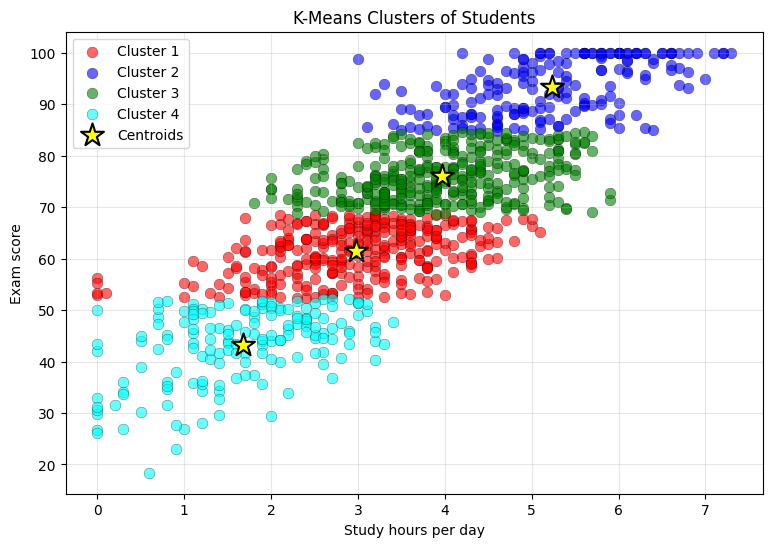

In [30]:
plt.figure(figsize=(9, 6))
colors = ['red', 'blue', 'green', 'cyan']
labels = ['Cluster 1', 'Cluster 2', 'Cluster 3', 'Cluster 4']
for i, (c, l) in enumerate(zip(colors, labels)):
    plt.scatter(X_clu[y_kmeans == i, 0], X_clu[y_kmeans == i, 1],
                s=60, c=c, label=l, alpha=0.6, edgecolor='k', linewidth=0.3)
plt.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1],
            s=300, c='yellow', marker='*', edgecolor='black', linewidth=1.5, label='Centroids')
plt.title('K-Means Clusters of Students')
plt.xlabel('Study hours per day')
plt.ylabel('Exam score')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

## Hierarchical Clustering (cross-check)

We also run **Agglomerative (Ward) clustering** on the same two features and inspect the dendrogram.

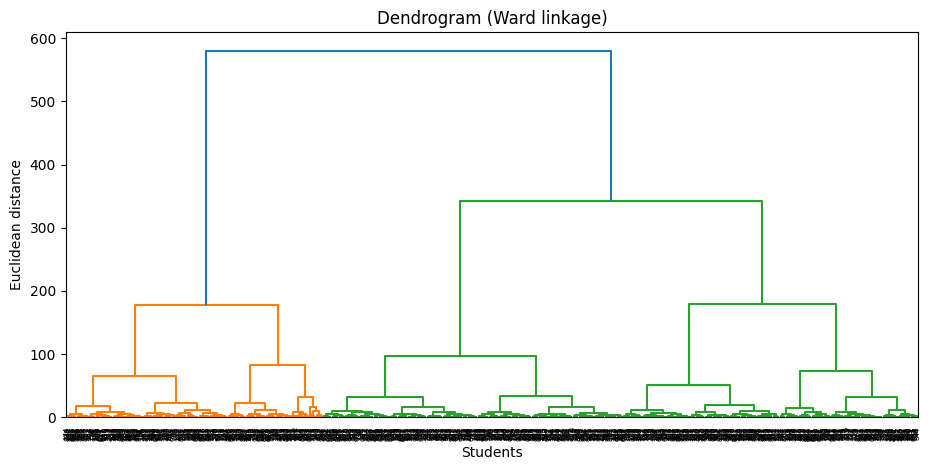

In [31]:
plt.figure(figsize=(11, 5))
dendrogram = sch.dendrogram(sch.linkage(X_clu, method='ward'))
plt.title('Dendrogram (Ward linkage)')
plt.xlabel('Students')
plt.ylabel('Euclidean distance')
plt.show()

Hierarchical cluster sizes: [296 159 344 180]


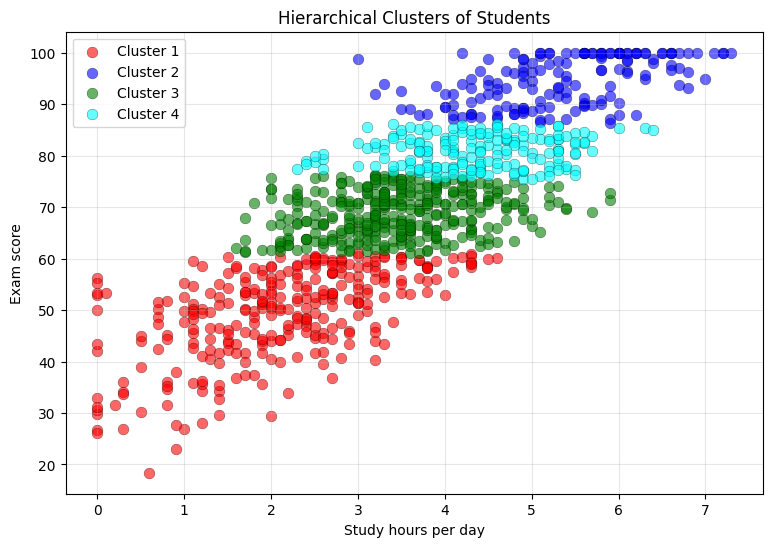

In [32]:
hc = AgglomerativeClustering(n_clusters=4, linkage='ward')
y_hc = hc.fit_predict(X_clu)
print('Hierarchical cluster sizes:', np.bincount(y_hc))

plt.figure(figsize=(9, 6))
for i, (c, l) in enumerate(zip(colors, labels)):
    plt.scatter(X_clu[y_hc == i, 0], X_clu[y_hc == i, 1],
                s=60, c=c, label=l, alpha=0.6, edgecolor='k', linewidth=0.3)
plt.title('Hierarchical Clusters of Students')
plt.xlabel('Study hours per day')
plt.ylabel('Exam score')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

## Cluster Profiles

In [33]:
profile_df = dataset.copy()
profile_df['cluster'] = y_kmeans
profile = profile_df.groupby('cluster').agg(
    size=('exam_score', 'size'),
    mean_study_hours=('study_hours_per_day', 'mean'),
    mean_exam_score=('exam_score', 'mean'),
    mean_attendance=('attendance_percentage', 'mean'),
    mean_sleep=('sleep_hours', 'mean'),
    mean_mental_health=('mental_health_rating', 'mean')
).round(2)
print(profile.to_string())

         size  mean_study_hours  mean_exam_score  mean_attendance  mean_sleep  mean_mental_health
cluster                                                                                          
0         302              2.97            61.38            82.80        6.26                4.88
1         183              5.23            93.39            85.64        6.71                6.83
2         333              3.97            76.04            84.74        6.55                5.83
3         161              1.68            43.30            83.64        6.39                4.07


## Strategy Formulation

Based on the profiles above, each cluster represents a distinct student segment with a recommended intervention. *(Cluster numbers correspond to K-Means labels printed above; if your run assigns labels in a different order, match by mean values rather than by integer label.)*

| Cluster centroid (study_h, score) | Segment name | Strategy |
|---|---|---|
| (~1.7 h, ~43) | **At-risk students** | Early-warning intervention: counselling, time-management support, mandatory tutoring. |
| (~3.0 h, ~61) | **Average performers** | Targeted study-skills workshops to push them toward the high-performer segment. |
| (~4.0 h, ~76) | **Above-average performers** | Focused coaching on weak topics; close to the top tier. |
| (~5.2 h, ~93) | **High performers** | Maintain through enrichment activities and peer-tutoring opportunities. |

# Conclusion

| CLO3 component | Outcome |
|---|---|
| **Preprocessing** | Imputed 91 missing values, encoded 6 categorical variables, removed 21 IQR outliers, scaled features. |
| **Regression** | Five models compared; **Lasso Regression** is best with MSE ≈ 30.70 and R² ≈ 0.887 — explains ~89% of the variance in `exam_score`. |
| **Classification** | Five classifiers compared; **Logistic Regression** is best with 96.4% accuracy on the held-out test set. |
| **Clustering** | K-Means with k = 4 produces four interpretable student segments, each with a tailored intervention strategy. |